In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import accuracy_score,f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [13]:
df = pd.read_csv('master.csv')

In [14]:
df = pd.read_csv('master.csv')

In [3]:
df.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [4]:
df.shape

(27820, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


In [7]:
df.describe()

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
count,27820.000000,27820.000000,2.782000e+04,27820.000000,8364.000000,27820.000000
mean,2001.258375,242.574407,1.844794e+06,12.816097,0.776601,16866.464414
std,8.469055,902.047917,3.911779e+06,18.961511,0.093367,18887.576472
min,1985.000000,0.000000,2.780000e+02,0.000000,0.483000,251.000000
25%,1995.000000,3.000000,9.749850e+04,0.920000,0.713000,3447.000000
50%,2002.000000,25.000000,4.301500e+05,5.990000,0.779000,9372.000000
75%,2008.000000,131.000000,1.486143e+06,16.620000,0.855000,24874.000000
max,2016.000000,22338.000000,4.380521e+07,224.970000,0.944000,126352.000000


In [18]:
df = df.drop(columns=['HDI for year','gdp_per_capita ($)'],axis=1)

In [19]:
df

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,gdp_for_year ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,"2,156,624,900",Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,"2,156,624,900",Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,"2,156,624,900",Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,"2,156,624,900",G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,"2,156,624,900",Boomers
...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,"63,067,077,179",Generation X
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,"63,067,077,179",Silent
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,"63,067,077,179",Generation Z
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,"63,067,077,179",Generation Z


In [23]:
df.corr(numeric_only=True)

,year,suicides_no,population,suicides/100k pop
year,1.000000,-0.004546,0.008850,-0.039037
suicides_no,-0.004546,1.000000,0.616162,0.306604
population,0.008850,0.616162,1.000000,0.008285
suicides/100k pop,-0.039037,0.306604,0.008285,1.000000


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='age', ylabel='Count'>

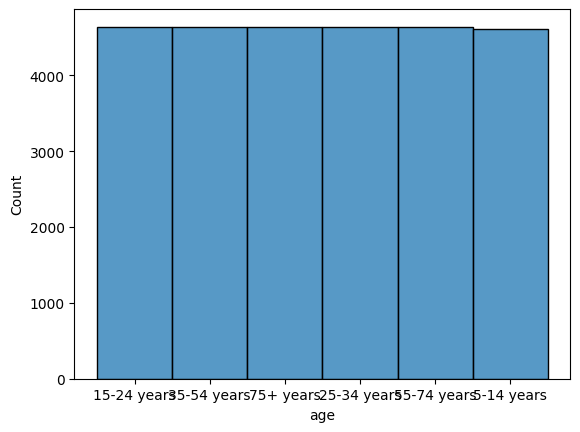

In [38]:
sns.histplot(x='age',discrete=True,data=df)

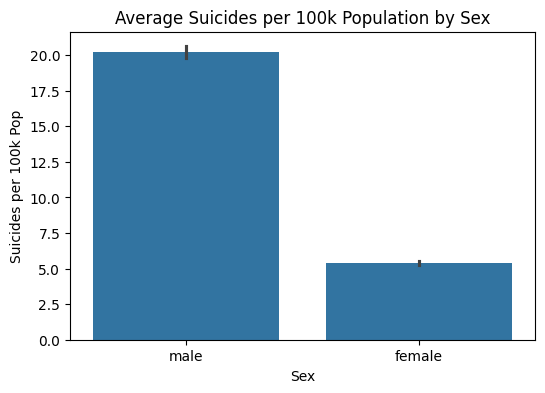

In [43]:
plt.figure(figsize=(6, 4))
sns.barplot(x='sex', y='suicides/100k pop', data=df)
plt.title('Average Suicides per 100k Population by Sex')
plt.ylabel('Suicides per 100k Pop')
plt.xlabel('Sex')
plt.show()

In [44]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,year,suicides_no,population,suicides/100k pop
year,1.000000,-0.004546,0.008850,-0.039037
suicides_no,-0.004546,1.000000,0.616162,0.306604
population,0.008850,0.616162,1.000000,0.008285
suicides/100k pop,-0.039037,0.306604,0.008285,1.000000


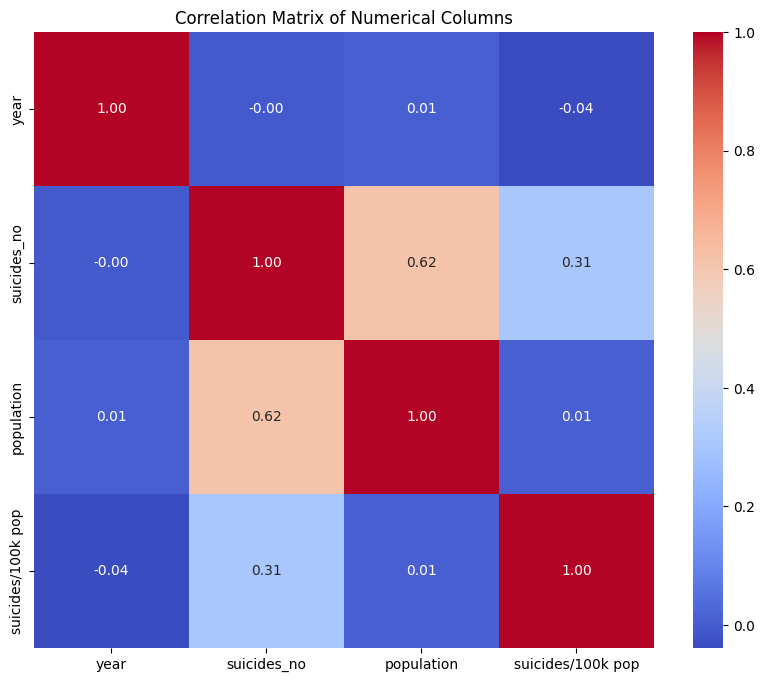

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

### Suicides per 100k population over the years

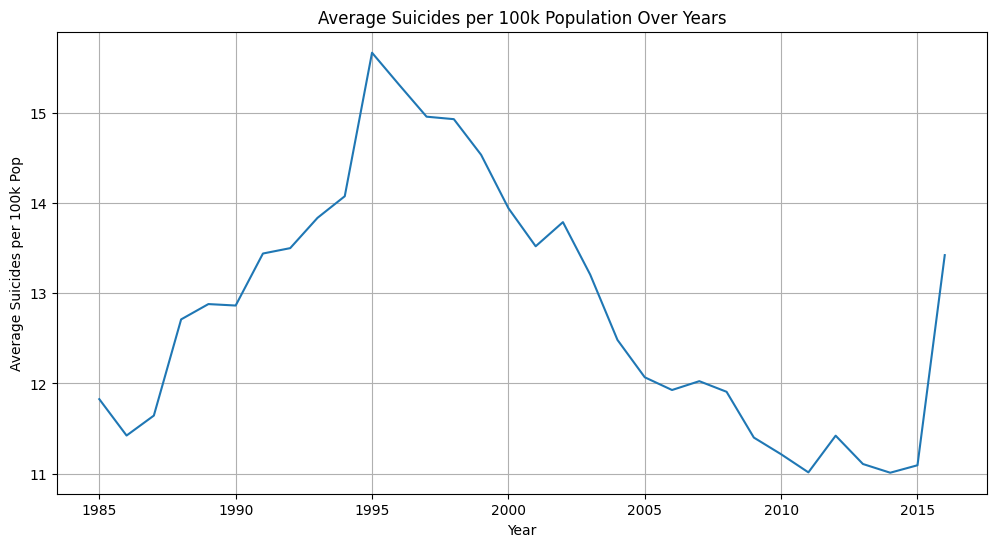

In [46]:
plt.figure(figsize=(12, 6))
year_suicides = df.groupby('year')['suicides/100k pop'].mean().reset_index()
sns.lineplot(x='year', y='suicides/100k pop', data=year_suicides)
plt.title('Average Suicides per 100k Population Over Years')
plt.xlabel('Year')
plt.ylabel('Average Suicides per 100k Pop')
plt.grid(True)
plt.show()

### Top 10 Countries by Average Suicides per 100k Population

/tmp/ipykernel_1923/3029350225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='suicides/100k pop', y='country', data=country_suicides, palette='viridis')


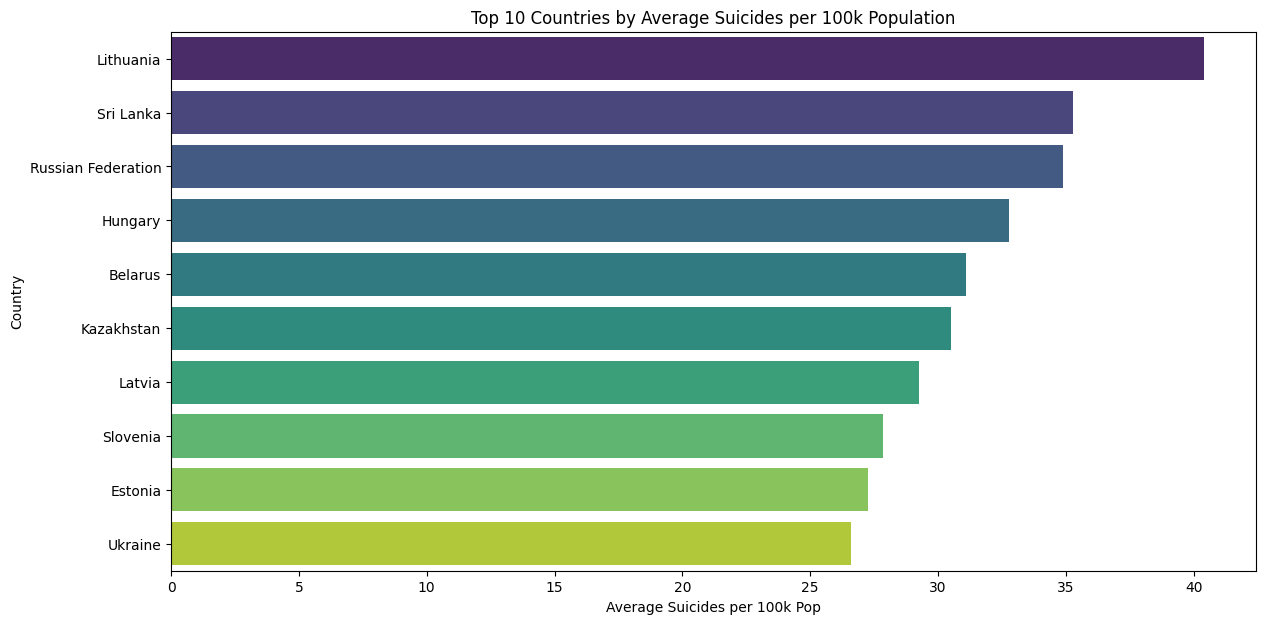

In [47]:
plt.figure(figsize=(14, 7))
country_suicides = df.groupby('country')['suicides/100k pop'].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x='suicides/100k pop', y='country', data=country_suicides, palette='viridis')
plt.title('Top 10 Countries by Average Suicides per 100k Population')
plt.xlabel('Average Suicides per 100k Pop')
plt.ylabel('Country')
plt.show()

### Scatter Plot of Suicides per 100k Population vs. Year, Colored by Sex

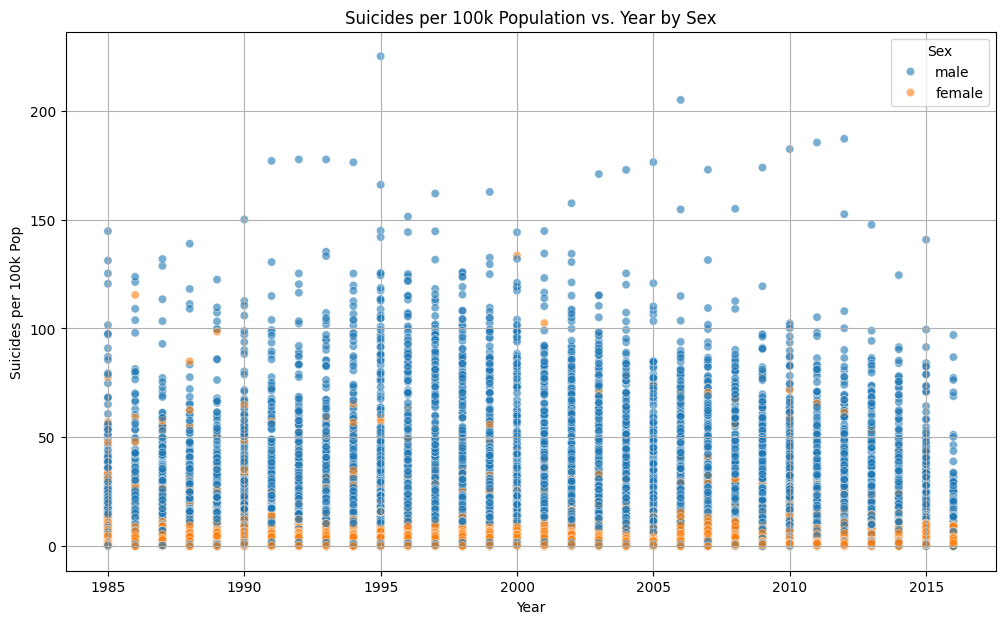

In [48]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='year', y='suicides/100k pop', hue='sex', data=df, alpha=0.6)
plt.title('Suicides per 100k Population vs. Year by Sex')
plt.xlabel('Year')
plt.ylabel('Suicides per 100k Pop')
plt.grid(True)
plt.legend(title='Sex')
plt.show()

### Data Cleaning: Prepare 'gdp_for_year ($)' and all Column Names

To ensure consistent access and correct type conversion, we will first strip any leading/trailing whitespace from all column names in the DataFrame. Then, we'll convert the 'gdp_for_year ($)' column from an object type (which contains string values with commas) to a float type.

In [61]:
# Strip whitespace from all column names
df.columns = df.columns.str.strip()

# Convert 'gdp_for_year ($)' to float by removing commas
df['gdp_for_year ($)'] = df['gdp_for_year ($)'].str.replace(',', '', regex=False).astype(float)

### Redefine X, y and Split Data

Now that 'gdp_for_year ($)' is numeric, we need to redefine our features (`X`) and target (`y`) based on the cleaned DataFrame and split the data into training and testing sets again.

In [62]:
X = df.drop(columns=['sex'])
y = df['sex']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Preprocessing with ColumnTransformer (One-Hot Encoding and Scaling)

We will use a `ColumnTransformer` to apply `OneHotEncoder` to nominal categorical features and `StandardScaler` to numerical features. This ensures that all features are in a suitable numerical format for the `LogisticRegression` model.

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['country', 'age', 'generation', 'country-year']
numerical_features = ['year', 'suicides_no', 'population', 'suicides/100k pop']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### Target Encoding for Test Set

Now, encode the `y_test` variable using the `LabelEncoder` that was previously fitted on `y_train`.

In [64]:
y_test_transformed = le.transform(y_test)

### Model Training: Logistic Regression

We will now train the `LogisticRegression` model using the preprocessed training data (`X_train_processed`) and the transformed training target (`y_transformed`).

In [65]:
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model.fit(X_train_processed, y_transformed)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

### Model Evaluation

Finally, we will evaluate the trained model's performance on the preprocessed test set (`X_test_processed`) using the accuracy and F1-score metrics against the transformed test target (`y_test_transformed`).

In [66]:
y_pred = model.predict(X_test_processed)

accuracy = accuracy_score(y_test_transformed, y_pred)
f1 = f1_score(y_test_transformed, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model F1 Score: {f1:.4f}")

Model Accuracy: 0.7586
Model F1 Score: 0.7430
